tf_flowers: This is a widely used dataset containing approximately 3,700 images across five common classes: daisy, dandelion, roses, sunflowers, and tulips. These flower groups(classes) are (i) Daisy, (ii) Dandelion, (iii) Roses, (iv) Sunflowers, and (v) Tulips. This image dataset stored on disk which are in jpg format.

In [ ]:
# Import necessary libraries

import matplotlib.pyplot as plt
import numpy as np
import os
import PIL  # Python Imaging Library (PIL)
import tensorflow as tf # TensorFlow is an open-source machine learning framework created by the Google Brain team
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import glob # The glob module finds all the pathnames matching a specified pattern
import pathlib #  Representing filesystem paths with semantics appropriate for different operating systems
import matplotlib
import matplotlib.image as mpimg # to display an image (a NumPy array) in a Matplotlib plot. It interprets a 2D array as a grayscale image by default, using a colormap, and a 3D array as an RGB or RGBA image.
import tarfile
import sys
from collections import Counter

In [ ]:
# Check versions
print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__) # tf.version.VERSION
print("Keras version:", tf.keras.__version__)
print("Python version",sys.version)
#print("Py Plot version:",plt.__version__)
print("Matplotlib version: " , matplotlib.__version__)

NumPy version: 2.0.2
TensorFlow version: 2.19.0
Keras version: 3.10.0
Python version 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Matplotlib version:  3.10.0


In [ ]:
# Download and explore the dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz" # A compressed archive (tar + gzip)
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True) # Download and Unzips / untars the .tgz file
# Returns the path to the extracted folder
data_dir = pathlib.Path(data_dir) / "flower_photos"

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# check the directory
print(data_dir)
print([p.name for p in data_dir.iterdir()])


/root/.keras/datasets/flower_photos/flower_photos
['roses', 'LICENSE.txt', 'tulips', 'dandelion', 'sunflowers', 'daisy']


In [ ]:
# Count total number of images in the dataset. daisy: 633, dandelion: 898, roses: 641, sunflowers: 699,  tulips: 799
# Daisy
daisy_count = len(list(data_dir.glob('daisy/*.jpg'))) # The glob module finds all the pathnames matching a specified pattern
# Dandelion
dandelion_count = len(list(data_dir.glob('dandelion/*.jpg')))
# Roses
roses_count = len(list(data_dir.glob('roses/*.jpg')))
# Sunflowers
sunflowers_count = len(list(data_dir.glob('sunflowers/*.jpg')))
# Tulips
tulips_count = len(list(data_dir.glob('tulips/*.jpg')))

# Total
# Total flowers. All subfolders, then all jpg files
image_count = len(list(data_dir.glob('*/*.jpg')))

# Display
print("Total number of Daisy: ",daisy_count)
print("Total number of Dandelion: ",dandelion_count)
print("Total number of Roses: ",roses_count)
print("Total number of Sunflowers: ",sunflowers_count)
print("Total number of Tulips: ",tulips_count)
print("Total number of images in the dataset: ",image_count)

Total number of Daisy:  633
Total number of Dandelion:  898
Total number of Roses:  641
Total number of Sunflowers:  699
Total number of Tulips:  799
Total number of images in the dataset:  3670


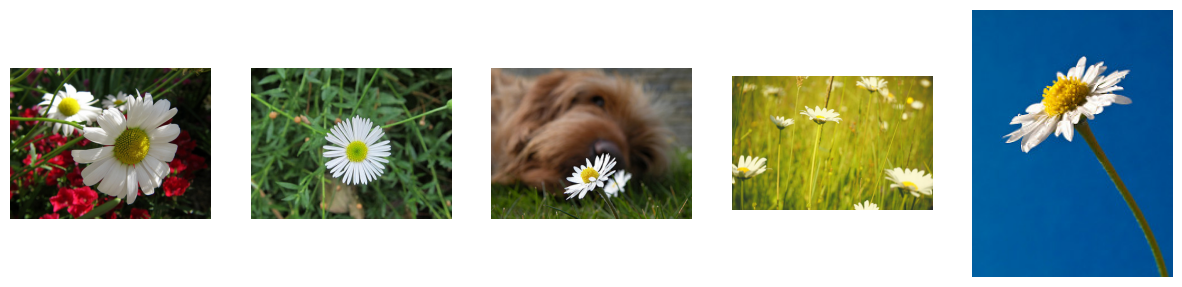

In [ ]:
# Let's look into only "daisy" subfolder
daisies = list(data_dir.glob('daisy/*'))
#PIL.Image.open(roses[1])
# Display the first 5 images from the list
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(daisies[i])
    plt.imshow(img)
    plt.axis('off')
plt.show()

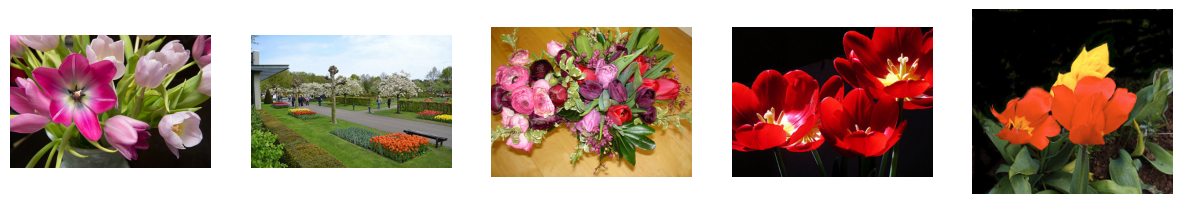

In [ ]:
# Display some tulips
tulips = list(data_dir.glob('tulips/*'))
# Display the first 5 images from the list
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(tulips[i])
    plt.imshow(img)
    plt.axis('off')
plt.show()

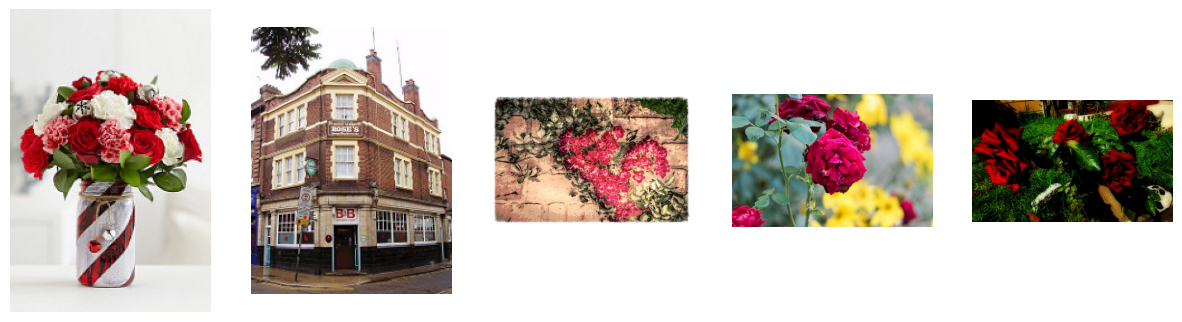

In [ ]:
# Display some roses
roses = list(data_dir.glob('roses/*'))
# Display the first 5 images from the list
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(roses[i])
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [ ]:
# Create a dataset for ML model
# Parameters, Set image size and number of images in each batch
batch_size = 32
img_height = 180
img_width = 180

In [ ]:
# Data preprocessing
# Generates a tf.data.Dataset from image files in a directory by using tf.keras.preprocessing.image_dataset_from_directory.
# It automatically loads images, assigns labels, resizes them, batches them, and creates a training dataset.
# The tf.keras.preprocessing.image_dataset_from_directory() utility function in TensorFlow is used to generate a tf.data.Dataset object from image files organized in a directory structure.

# Split the image dataset into 8:2. Use 80% of the images for training, and 20% for validation
# Training data set
train_ds = tf.keras.preprocessing.image_dataset_from_directory( # https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123, # Ensure reproducibiliy. Without this Every run may create a different random split.
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [ ]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
# Print labels from one batch
image_batch, label_batch = next(iter(train_ds))

print("Labels in this batch:")
print(label_batch.numpy())
print("Batch of",len(label_batch.numpy()))

Labels in this batch:
[2 1 4 3 1 2 1 2 4 1 4 4 3 4 1 2 0 4 1 1 1 4 3 2 3 1 4 2 2 3 4 3]
Batch of 32


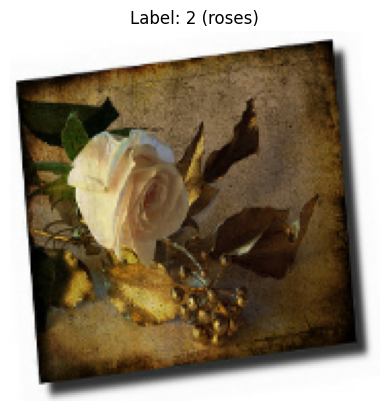

In [ ]:
# Display one image with its label
#image_batch, label_batch = next(iter(train_ds))
# Get class name
class_names = train_ds.class_names

plt.imshow(image_batch[0].numpy().astype("uint8"))
plt.title(f"Label: {label_batch[0].numpy()} ({class_names[label_batch[0].numpy()]})")
plt.axis("off")
plt.show()

In [ ]:
train_ds.class_names

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

In [ ]:
# Count images per class from train_ds
# Get class names (folder names in order of labels)
class_names = train_ds.class_names
print("Class names:", class_names)

# Initialize counter
counter = Counter()

# Loop through all batches in train_ds
for images, labels in train_ds:
    counter.update(labels.numpy())

# Display counts
total = 0
print("\nNumber of images per class in TRAINING set:")
for i, class_name in enumerate(class_names):
    count = counter[i]
    total += count
    print(f"{class_name:12s}: {count} images")

print("\nTotal training images:", total)

Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Number of images per class in TRAINING set:
daisy       : 504 images
dandelion   : 722 images
roses       : 521 images
sunflowers  : 547 images
tulips      : 642 images

Total training images: 2936


In [ ]:
# validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
# Count images per class from val_ds
# Get class names (folder names in order of labels)
class_names = val_ds.class_names
print("Class names:", class_names)

# Initialize counter
counter = Counter()

# Loop through all batches in train_ds
for images, labels in val_ds:
    counter.update(labels.numpy())

# Display counts
total = 0
print("\nNumber of images per class in Validation set:")
for i, class_name in enumerate(class_names):
    count = counter[i]
    total += count
    print(f"{class_name:12s}: {count} images")

print("\nTotal validation images:", total)

Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Number of images per class in Validation set:
daisy       : 129 images
dandelion   : 176 images
roses       : 120 images
sunflowers  : 152 images
tulips      : 157 images

Total validation images: 734


In [ ]:
# check the class names in the class_names attribute on these datasets
class_names = train_ds.class_names
print(class_names)
val_class_names = val_ds.class_names
print(val_class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


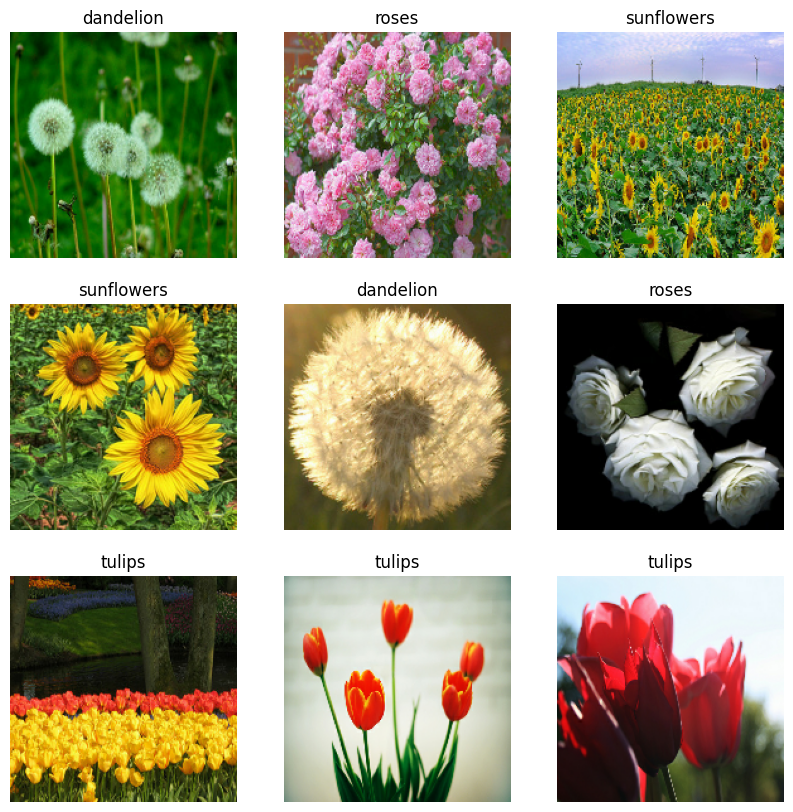

In [ ]:
# Visualize the data
# Show 9 images from train dataset with image labels.
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
# To get information about a numpy array, we can use .shape and .dtype
# The image_batch is a tensor of the shape (32, 180, 180, 3). This is a batch of 32 images of shape 180x180x3 (the last dimension refers to color channels RGB).
# The label_batch is a tensor of the shape (32,), these are corresponding labels to the 32 images.


for image_batch, labels_batch in train_ds:
   print("Shape of image batch:", image_batch.shape)
   print("Data type of image batch:", image_batch.dtype)
   print("Shape of label batch:", labels_batch.shape)
   print("Data type of label batch:", labels_batch.dtype)
   break


Shape of image batch: (32, 180, 180, 3)
Data type of image batch: <dtype: 'float32'>
Shape of label batch: (32,)
Data type of label batch: <dtype: 'int32'>


In [ ]:
# tf.data.Dataset is NOT an array but is a pipeline object that yields tensors (batches of images and labels).
# Take one batch from train_ds
image_batch, label_batch = next(iter(train_ds))
# Select the first image in the batch
img0 = image_batch[0].numpy()

print(img0)


[[[255.        255.        255.       ]
  [255.        255.        255.       ]
  [255.        255.        255.       ]
  ...
  [252.3389    251.3389    230.9139   ]
  [252.53334   251.53334   232.68335  ]
  [252.725     251.725     232.875    ]]

 [[255.        255.        255.       ]
  [255.        255.        255.       ]
  [255.        255.        255.       ]
  ...
  [253.15277   252.12222   230.45     ]
  [254.24165   252.4833    230.45     ]
  [254.45      253.09447   230.09447  ]]

 [[255.        255.        255.       ]
  [255.        255.        255.       ]
  [255.        255.        255.       ]
  ...
  [253.        251.        228.88892  ]
  [252.74997   250.5833    227.41663  ]
  [253.5278    251.5278    228.5278   ]]

 ...

 [[ 83.166664   74.958336   27.333332 ]
  [ 37.416664   43.249996   20.166668 ]
  [ 39.40278    47.51389    26.166668 ]
  ...
  [123.22278   113.931      50.97223  ]
  [ 12.916702   13.29158     2.8750076]
  [ 89.47067    77.63843     4.6528625]]

 [

In [ ]:
img0[50,50,:]

array([72.558495, 76.75283 , 32.608425], dtype=float32)

In [ ]:
# Configure the dataset for performance
# This block is not about learning, but about making the CNN training much faster and more efficient by optimizing the data input pipeline. This is a performance optimization pipeline using TensorFlow’s tf.data API.
# Use buffered prefetching to yield data from disk without having I/O become blocking
# Dataset.cache() keeps the images in memory after they're loaded off disk during the first epoch.
# This will ensure the dataset does not become a bottleneck while training your model.
# Dataset.prefetch() overlaps data preprocessing and model execution while training.

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Standardize the data
# Preprocess images by normalizing the pixel values to be in the [0, 1] range (originally all values are in the [0, 255] range).
# All images will be rescaled by 1./255 (min-max normalization)

# Take one batch (1st) from the training dataset
image_batch, labels_batch = next(iter(train_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,255]`.
print("Before Normalization: ",np.min(first_image), np.max(first_image))

# Rescaling layer (min-max)
normalization_layer = layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

# Take one batch (1st) from the normalized dataset
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,1]`.
print("After Normalization: ", np.min(first_image), np.max(first_image))

Before Normalization:  0.0 254.84721
After Normalization:  0.0 0.9998258


In [ ]:
# Create the model
# The model consists of three convolution blocks with a max pool layer in each of them.
# There's a fully connected layer with 128 units on top of it that is activated by a relu activation function.

num_classes = 5

model = Sequential([
  # All images will be rescaled by 1./255 (min-max normalization)
  # Image shape is (180x180x3)
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

  # First convolution extracts 16 filters that are 3x3
  # Convolution is followed by max-pooling layer with a 2x2 window
  # Relu overcome vanishing gradient prolem, learning faster and better. Relu is default for Convolutional Neural Network.
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Second convolution extracts 32 filters that are 3x3
  # Convolution is followed by max-pooling layer with a 2x2 window
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Third convolution extracts 64 filters that are 3x3
  # Convolution is followed by max-pooling layer with a 2x2 window
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Flatten feature map to a 1-dim tensor so we can add fully connected layers
  layers.Flatten(),

  # Create a fully connected layer with ReLU activation and 128 hidden units
  layers.Dense(128, activation='relu'),

 # Create output layer with five classifier
  layers.Dense(num_classes) # There is NO activation function here!
  # This means, Output = raw scores (logits). Later, when compiling, I use, loss = SparseCategoricalCrossentropy(from_logits=True). meaning, Softmax is applied internally during loss computation
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
# Using the optimizers as Adam optimizer and losses, SparseCategoricalCrossentropy loss function.
# To view training and validation accuracy for each training epoch, pass the metrics argument.

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [ ]:
# Train the model
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  verbose = 2
)

Epoch 1/10
92/92 - 13s - 142ms/step - accuracy: 0.3617 - loss: 1.5052 - val_accuracy: 0.5000 - val_loss: 1.1936
Epoch 2/10
92/92 - 11s - 116ms/step - accuracy: 0.5739 - loss: 1.0844 - val_accuracy: 0.5858 - val_loss: 1.0128
Epoch 3/10
92/92 - 2s - 18ms/step - accuracy: 0.6485 - loss: 0.8989 - val_accuracy: 0.6540 - val_loss: 0.8884
Epoch 4/10
92/92 - 2s - 18ms/step - accuracy: 0.7371 - loss: 0.7064 - val_accuracy: 0.6526 - val_loss: 0.8998
Epoch 5/10
92/92 - 2s - 18ms/step - accuracy: 0.8055 - loss: 0.5410 - val_accuracy: 0.6349 - val_loss: 0.9372
Epoch 6/10
92/92 - 2s - 18ms/step - accuracy: 0.8801 - loss: 0.3447 - val_accuracy: 0.6567 - val_loss: 1.0684
Epoch 7/10
92/92 - 2s - 18ms/step - accuracy: 0.9322 - loss: 0.2040 - val_accuracy: 0.6390 - val_loss: 1.1861
Epoch 8/10
92/92 - 2s - 18ms/step - accuracy: 0.9636 - loss: 0.1166 - val_accuracy: 0.6172 - val_loss: 1.5710
Epoch 9/10
92/92 - 2s - 18ms/step - accuracy: 0.9843 - loss: 0.0709 - val_accuracy: 0.5940 - val_loss: 1.8136
Epoch 

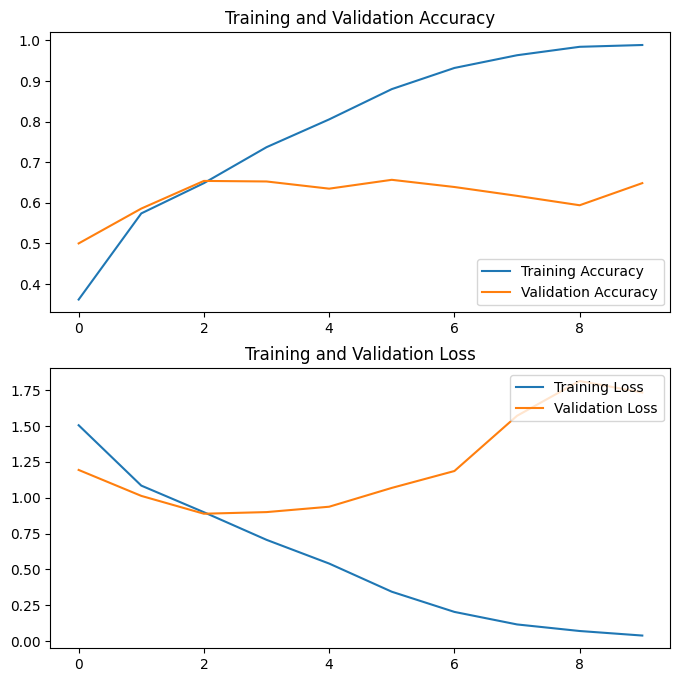

In [ ]:
# Visualize training results
# Create plots of loss and accuracy on the training and validation sets

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [ ]:
# print maximun accuracy on traning and validation data
# In the plots above, the training accuracy is increasing linearly over time, whereas validation accuracy stalls around 60% in the training process.
# Also, the difference in accuracy between training and validation accuracy is noticeable—a sign of overfitting.

print("Training Data Accuracy:",max(acc))
print("Validation Data Accuracy",max(val_acc))

Training Data Accuracy: 0.988760232925415
Validation Data Accuracy 0.6566757559776306


# What can we do to tackle overfitting issues?

In [ ]:
# Add Approach 1
# Re design the same model with dropout layer


num_classes =5

model2 = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  #layers.Dropout(0.2), # 20% dropout
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.2), # 20% dropout
  layers.Dense(num_classes)
])

In [ ]:
# Compile and train the model

model2.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
# Model summary

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
epochs = 10
history2 = model2.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  verbose = 1
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.3179 - loss: 1.7980 - val_accuracy: 0.5232 - val_loss: 1.1523
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5454 - loss: 1.1132 - val_accuracy: 0.5668 - val_loss: 1.0416
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6058 - loss: 0.9953 - val_accuracy: 0.6308 - val_loss: 0.9387
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7028 - loss: 0.7951 - val_accuracy: 0.6567 - val_loss: 0.8528
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7642 - loss: 0.6510 - val_accuracy: 0.6594 - val_loss: 0.8610
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8398 - loss: 0.4452 - val_accuracy: 0.6649 - val_loss: 0.9523
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8924 - loss: 0.3270 - val_accuracy: 0.6744 - val_loss: 1.0393
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9206 - loss: 0.2237 - val_accuracy: 0.6240 - 

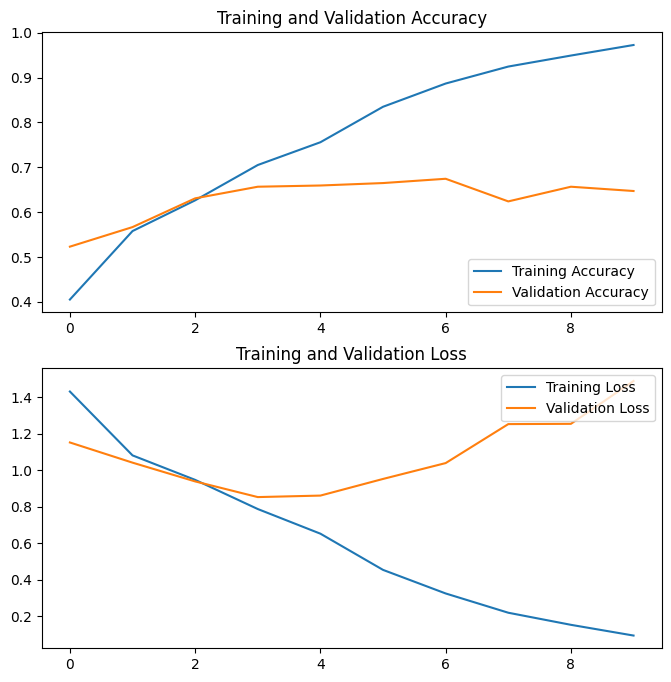

In [ ]:
# After applying data Dropout, there is less overfitting than before, and training and validation accuracy are closer aligned

acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']

loss = history2.history['loss']
val_loss = history2.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# Diplay basic statistics
print("The maximum training Data Accuracy:",max(acc))
print("The maximum validation Data Accuracy",max(val_acc))

The maximum training Data Accuracy: 0.9724114537239075
The maximum validation Data Accuracy 0.6743869185447693


# What can we do to tackle overfitting issues?

In [ ]:
# Use (i)data augmentation and (ii)add Dropout to your model to overcome "overfitting".
# Data augmentation takes the approach of generating additional training data from your existing examples by augmenting them using random transformations that yield believable-looking images.
# Implement data augmentation using the layers from tf.keras.layers.experimental.preprocessing. These can be included inside ML model like other layers, and run on the GPU.

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal",
    input_shape=(img_height,img_width,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)


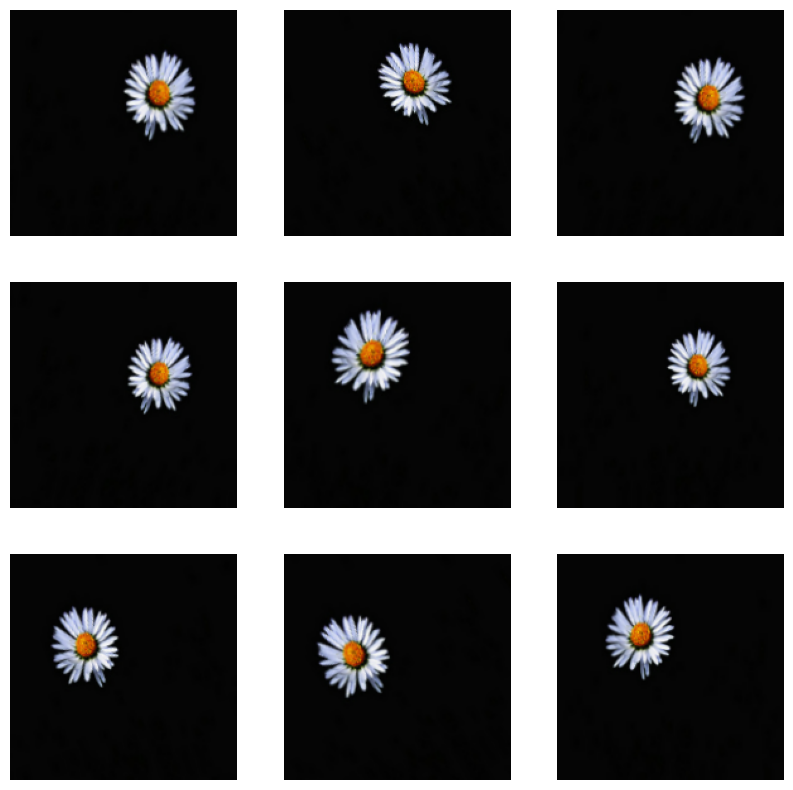

In [ ]:
# Let's visualize what a few augmented examples look like by applying data augmentation to the same image several times

plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [ ]:
# Re design the same model with dropout layer
# Dropout
# When we apply Dropout to a layer it randomly drops out (by setting the activation to zero) a number of output units from the layer during the training process.
# Create a new neural network using layers.Dropout, then train it using augmented images.

num_classes =5

model3 = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  #layers.Dropout(0.2), # 20% dropout
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.2),
  layers.Dense(num_classes)
])

In [ ]:
# Model summary

model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and train the model

model3.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
# Train the model
epochs = 15
history3 = model3.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  verbose = 1
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.3619 - loss: 1.4806 - val_accuracy: 0.6131 - val_loss: 1.0608
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5849 - loss: 1.0351 - val_accuracy: 0.6131 - val_loss: 0.9530
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6324 - loss: 0.9320 - val_accuracy: 0.6417 - val_loss: 0.9057
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6707 - loss: 0.8668 - val_accuracy: 0.6621 - val_loss: 0.9212
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7065 - loss: 0.7714 - val_accuracy: 0.6662 - val_loss: 0.9582
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7116 - loss: 0.7793 - val_accuracy: 0.6744 - val_loss: 0.8126
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7131 - loss: 0.7483 - val_accuracy: 0.7221 - val_loss: 0.7308
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7399 - loss: 0.7055 - val_accuracy: 0.7016 - v

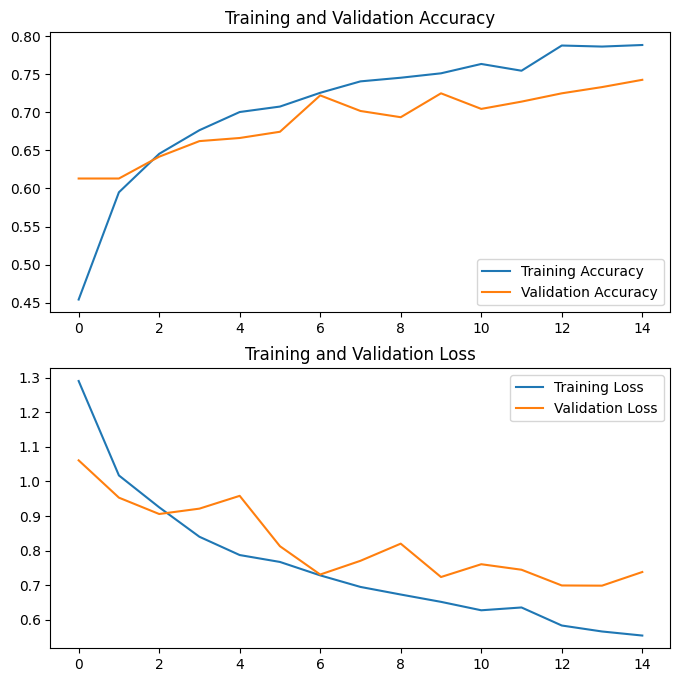

In [ ]:
# After applying data augmentation and Dropout, there is less overfitting than before, and training and validation accuracy are closer aligned

acc = history3.history['accuracy']
val_acc = history3.history['val_accuracy']

loss = history3.history['loss']
val_loss = history3.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# Diplay basic statistics
import statistics as st
print("The maximum training Data Accuracy:",max(acc))
print("The maximum validation Data Accuracy",max(val_acc))
print("Average training Data Accuracy:",st.mean(acc))
print("Average validation Data Accuracy",st.mean(val_acc))

The maximum training Data Accuracy: 0.7881471514701843
The maximum validation Data Accuracy 0.7425068020820618
Average training Data Accuracy: 0.7080381532510122
Average validation Data Accuracy 0.6887375076611837


In [ ]:
# Predict on new data
# Note: Data augmentation and Dropout layers are inactive at inference time.

sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

img = keras.preprocessing.image.load_img(
    sunflower_path, target_size=(img_height, img_width)
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch (of zero)

predictions = model3.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
This image most likely belongs to sunflowers with a 98.52 percent confidence.
